Boundary Suppression Optimization Analysis

This notebook analyzes the results of **boundary suppression** optimizations
using the AkitaSF framework (Ledidi + Semifreddo-Akita).

### Experimental design
- **Starting sequences:** strong, synthetic boundary sequences (high insulation score)
- **Editable region:** central bin, excluding existing CTCF motifs
- **Objective:** weaken the boundary (reduce insulation score)
- **Control:** unoptimized sequences run through the same pipeline

We compare optimized sequences against controls across three axes:
1. **Insulation score** — the primary optimization target
2. **CTCF motif count** — to check whether CTCF exclusion holds and whether motifs are gained/lost
3. **GC content** — to detect sequence composition drift in the edited region

## 1. Imports & paths

In [4]:
import os
import sys

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))
from utils.df_utils import simple_load_results

BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundary_suppression/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RESULT_DIRS        = ["results"]
CONTROL_RESULT_DIRS = ["control"]
FOLDS              = range(8)

## 2. Load data

In [5]:
df         = simple_load_results(RESULT_DIRS,        BASE_DIR, FOLDS, "suppression_results.tsv")
control_df = simple_load_results(CONTROL_RESULT_DIRS, BASE_DIR, FOLDS, "suppression_results.tsv")

df["insul_score_diff"]    = df["insul_score_edited"] - df["insul_score_orig"]
df["optimization_success"] = df["insul_score_diff"] > 0

print(f"Loaded {len(df)} optimized windows across {df['fold'].nunique()} folds")
print(f"Loaded {len(control_df)} control windows across {control_df['fold'].nunique()} folds")
print(f"\nSuccessful optimizations: {df['optimization_success'].sum()} / {len(df)} "
      f"({100 * df['optimization_success'].mean():.1f}%)")

Loaded 323 optimized windows across 8 folds
Loaded 323 control windows across 8 folds

Successful optimizations: 323 / 323 (100.0%)


## 3. Insulation score

The insulation score is the primary optimization target. We expect edited optimized
sequences to show higher insulation scores (i.e., *weaker* boundaries) relative to
their initial state, while control sequences should remain unchanged.

> **Note:** A higher insulation score corresponds to a *weaker* boundary in the Akita
> convention — a positive `insul_score_diff` means successful suppression.

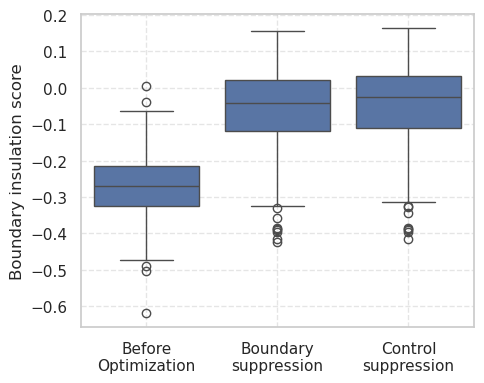

In [6]:
plot_df = pd.melt(
    pd.concat([
        df[["insul_score_orig", "insul_score_edited"]].assign(group="optimized"),
        control_df[["insul_score_edited"]].assign(group="control"),
    ]),
    id_vars="group",
    value_vars=["insul_score_orig", "insul_score_edited"],
    var_name="condition",
    value_name="insul_score",
)
plot_df["x"] = plot_df["group"] + "\n" + plot_df["condition"].map(
    {"insul_score_orig": "(initial)", "insul_score_edited": "(edited)"}
)
ORDER = ["optimized\n(initial)", "optimized\n(edited)", "control\n(edited)"]

plt.figure(figsize=(5, 4))
sns.boxplot(data=plot_df, x="x", y="insul_score", order=ORDER)

new_labels = ["Before\nOptimization", "Boundary\nsuppression", "Control\nsuppression"]
plt.xticks(ticks=range(len(ORDER)), labels=new_labels)
plt.ylabel("Boundary insulation score")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. CTCF motif count

CTCF motifs are **excluded** from the editable region during optimization, so the CTCF
count should remain equal to the initial count. Any deviation would indicate motif
creation in non-excluded positions or a masking error.

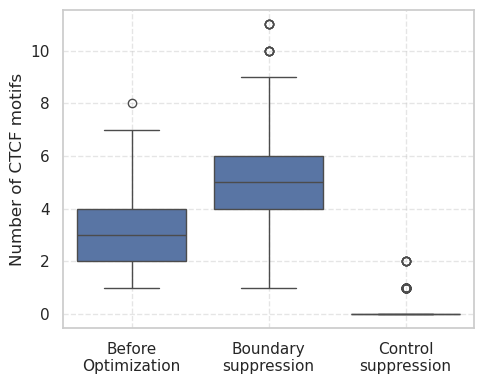

In [7]:
plot_df = pd.melt(
    pd.concat([
        df[["init_CTCFs_num", "CTCFs_num"]].assign(group="optimized"),
        control_df[["init_CTCFs_num", "CTCFs_num"]].assign(group="control"),
    ]),
    id_vars="group",
    value_vars=["init_CTCFs_num", "CTCFs_num"],
    var_name="condition",
    value_name="ctcf_count",
)
plot_df["x"] = plot_df["group"] + "\n" + plot_df["condition"].map(
    {"init_CTCFs_num": "(initial)", "CTCFs_num": "(edited)"}
)

plt.figure(figsize=(5, 4))
sns.boxplot(data=plot_df, x="x", y="ctcf_count", order=ORDER)
new_labels = ["Before\nOptimization", "Boundary\nsuppression", "Control\nsuppression"]
plt.xticks(ticks=range(len(ORDER)), labels=new_labels)
plt.ylabel("Number of CTCF motifs")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig(PLOTS_DIR / "boundary_suppression_ctcf_count.svg", format="svg")
plt.show()

## 5. GC content of the edited region

GC content is tracked in the **editable slice** of the sequence only.

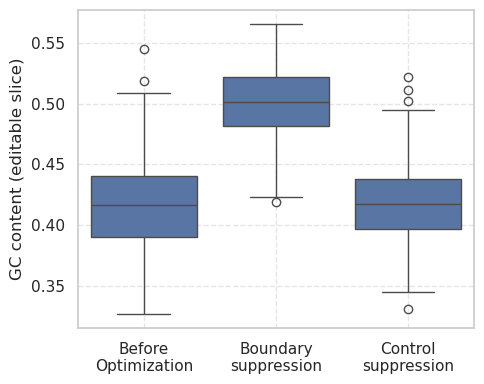

In [8]:
plot_df = pd.melt(
    pd.concat([
        df[["GC_slice_orig", "GC_slice_edited"]].assign(group="optimized"),
        control_df[["GC_slice_orig", "GC_slice_edited"]].assign(group="control"),
    ]),
    id_vars="group",
    value_vars=["GC_slice_orig", "GC_slice_edited"],
    var_name="condition",
    value_name="gc_content",
)
plot_df["x"] = plot_df["group"] + "\n" + plot_df["condition"].map(
    {"GC_slice_orig": "(initial)", "GC_slice_edited": "(edited)"}
)

plt.figure(figsize=(5, 4))
sns.boxplot(data=plot_df, x="x", y="gc_content", order=ORDER)
new_labels = ["Before\nOptimization", "Boundary\nsuppression", "Control\nsuppression"]
plt.xticks(ticks=range(len(ORDER)), labels=new_labels)
plt.ylabel("GC content (editable slice)")
plt.xlabel("")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig(PLOTS_DIR / "boundary_suppression_gc_content.svg", format="svg")
plt.show()

## 6. GC content: optimized slices vs. training data

To check whether the optimizer drives sequences into out-of-distribution GC content,
we compare the GC content of the **edited slices** (2048 bp editable region) against
the GC content distribution of all 2048 bp windows in the training data.

In [9]:
GC_TRAINING_PATH = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundary_suppression/gc_content_training_data.tsv")

gc_training = pd.read_csv(GC_TRAINING_PATH, sep="\t")["gc_content"]  # adjust column name if needed
gc_edited   = df["GC_slice_edited"]

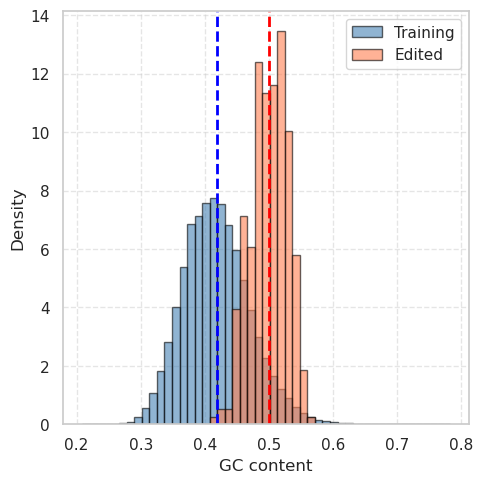

Training GC — mean: 0.418, std: 0.052
Edited GC   — mean: 0.500, std: 0.028


In [10]:
bins = np.linspace(
    min(gc_training.min(), gc_edited.min()),
    max(gc_training.max(), gc_edited.max()),
    50,
)

plt.figure(figsize=(5, 5))
plt.hist(gc_training, bins=bins, alpha=0.6, label="Training", color="steelblue", density=True, edgecolor="black")
plt.hist(gc_edited,   bins=bins, alpha=0.6, label="Edited",   color="coral",     density=True, edgecolor="black")
plt.axvline(gc_training.mean(), color="blue", linestyle="--", linewidth=2)
plt.axvline(gc_edited.mean(),   color="red",  linestyle="--", linewidth=2)
plt.xlabel("GC content")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.savefig(PLOTS_DIR / "boundary_suppression_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

print(f"Training GC — mean: {gc_training.mean():.3f}, std: {gc_training.std():.3f}")
print(f"Edited GC   — mean: {gc_edited.mean():.3f}, std: {gc_edited.std():.3f}")